# Классификация методом K ближайших соседей (KNN)
## GridSearchCV · RandomizedSearchCV · Кросс-валидация

---

## 1. Описание датасета

**Breast Cancer Wisconsin (Diagnostic)** — классический датасет для бинарной классификации из библиотеки `sklearn.datasets`. Содержит характеристики ядер клеток, вычисленных по изображениям биопсий молочной железы.

| Параметр | Значение |
|---|---|
| Объём выборки | 569 наблюдений |
| Количество признаков | 30 числовых |
| Целевая переменная | `target` — 0 (злокачественная) / 1 (доброкачественная) |
| Распределение классов | 212 злокачественных / 357 доброкачественных |
| Пропуски | отсутствуют |
| Категориальные признаки | отсутствуют |

Признаки описывают геометрические и текстурные характеристики клеточных ядер: радиус, периметр, площадь, гладкость, компактность и др. Для каждой характеристики вычислены среднее, стандартное отклонение и наихудшее значение (итого 10 × 3 = 30 признаков).

**Задача**: бинарная классификация — предсказать, является ли опухоль злокачественной (0) или доброкачественной (1).

In [11]:
# ─────────────────────────────────────────────────
#  Импорт библиотек
# ─────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import (
    train_test_split, GridSearchCV, RandomizedSearchCV,
    StratifiedKFold, KFold, cross_val_score
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, roc_curve
)

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110
pd.set_option('display.float_format', '{:.4f}'.format)

# ─────────────────────────────────────────────────
#  Загрузка данных
# ─────────────────────────────────────────────────
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

print(f'Форма датасета:      {df.shape}')
print(f'Пропуски:            {df.isnull().sum().sum()}')
print(f'Распределение классов:\n{df["target"].value_counts().rename({0:"Malignant (0)", 1:"Benign (1)"}).to_string()}')
df.head()

Форма датасета:      (569, 31)
Пропуски:            0
Распределение классов:
target
Benign (1)       357
Malignant (0)    212


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.9900,10.3800,122.8000,1001.0000,0.1184,0.2776,0.3001,0.1471,0.2419,0.0787,...,17.3300,184.6000,2019.0000,0.1622,0.6656,0.7119,0.2654,0.4601,0.1189,0
1,20.5700,17.7700,132.9000,1326.0000,0.0847,0.0786,0.0869,0.0702,0.1812,0.0567,...,23.4100,158.8000,1956.0000,0.1238,0.1866,0.2416,0.1860,0.2750,0.0890,0
2,19.6900,21.2500,130.0000,1203.0000,0.1096,0.1599,0.1974,0.1279,0.2069,0.0600,...,25.5300,152.5000,1709.0000,0.1444,0.4245,0.4504,0.2430,0.3613,0.0876,0
3,11.4200,20.3800,77.5800,386.1000,0.1425,0.2839,0.2414,0.1052,0.2597,0.0974,...,26.5000,98.8700,567.7000,0.2098,0.8663,0.6869,0.2575,0.6638,0.1730,0
4,20.2900,14.3400,135.1000,1297.0000,0.1003,0.1328,0.1980,0.1043,0.1809,0.0588,...,16.6700,152.2000,1575.0000,0.1374,0.2050,0.4000,0.1625,0.2364,0.0768,0


In [12]:
df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.0000,569.0000,569.0000,569.0000,569.0000,569.0000,569.0000,569.0000,569.0000,569.0000,...,569.0000,569.0000,569.0000,569.0000,569.0000,569.0000,569.0000,569.0000,569.0000,569.0000
mean,14.1273,19.2896,91.9690,654.8891,0.0964,0.1043,0.0888,0.0489,0.1812,0.0628,...,25.6772,107.2612,880.5831,0.1324,0.2543,0.2722,0.1146,0.2901,0.0839,0.6274
std,3.5240,4.3010,24.2990,351.9141,0.0141,0.0528,0.0797,0.0388,0.0274,0.0071,...,6.1463,33.6025,569.3570,0.0228,0.1573,0.2086,0.0657,0.0619,0.0181,0.4839
min,6.9810,9.7100,43.7900,143.5000,0.0526,0.0194,0.0000,0.0000,0.1060,0.0500,...,12.0200,50.4100,185.2000,0.0712,0.0273,0.0000,0.0000,0.1565,0.0550,0.0000
25%,11.7000,16.1700,75.1700,420.3000,0.0864,0.0649,0.0296,0.0203,0.1619,0.0577,...,21.0800,84.1100,515.3000,0.1166,0.1472,0.1145,0.0649,0.2504,0.0715,0.0000
50%,13.3700,18.8400,86.2400,551.1000,0.0959,0.0926,0.0615,0.0335,0.1792,0.0615,...,25.4100,97.6600,686.5000,0.1313,0.2119,0.2267,0.0999,0.2822,0.0800,1.0000
75%,15.7800,21.8000,104.1000,782.7000,0.1053,0.1304,0.1307,0.0740,0.1957,0.0661,...,29.7200,125.4000,1084.0000,0.1460,0.3391,0.3829,0.1614,0.3179,0.0921,1.0000
max,28.1100,39.2800,188.5000,2501.0000,0.1634,0.3454,0.4268,0.2012,0.3040,0.0974,...,49.5400,251.2000,4254.0000,0.2226,1.0580,1.2520,0.2910,0.6638,0.2075,1.0000


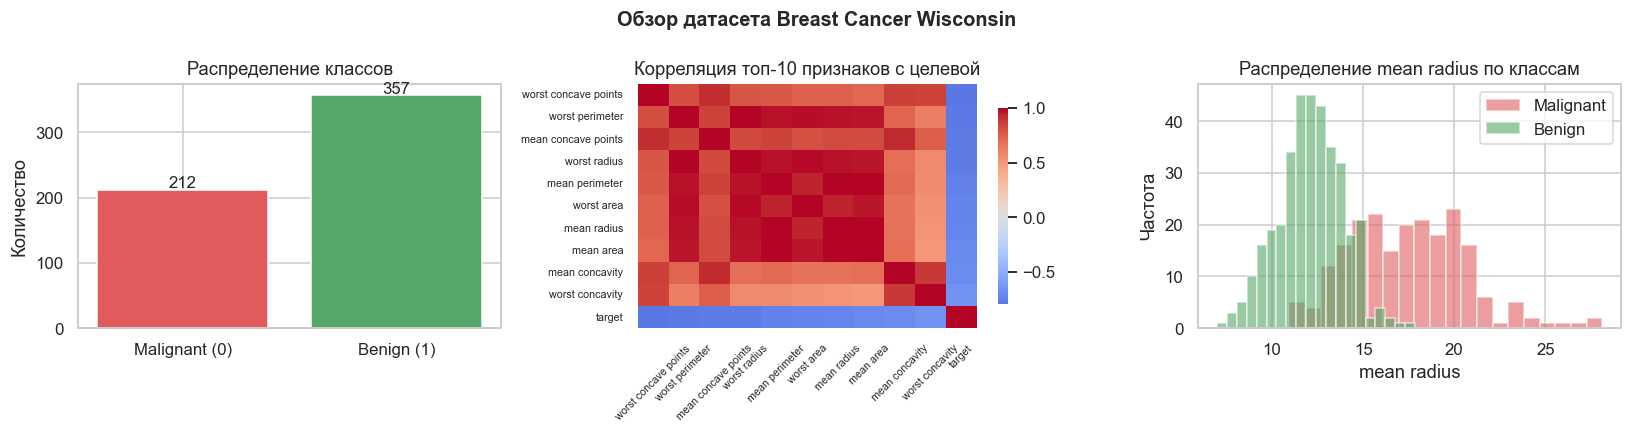

In [13]:
# Визуализация датасета
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Распределение классов
axes[0].bar(['Malignant (0)', 'Benign (1)'],
            df['target'].value_counts().sort_index(),
            color=['#E05C5C', '#55A868'], edgecolor='white')
axes[0].set_title('Распределение классов', fontsize=12)
axes[0].set_ylabel('Количество')
for i, v in enumerate(df['target'].value_counts().sort_index()):
    axes[0].text(i, v+3, str(v), ha='center', fontsize=11)

# Тепловая карта корреляций
top_feats = df.corr()['target'].abs().sort_values(ascending=False)[1:11].index
sns.heatmap(df[list(top_feats)+['target']].corr(), annot=False,
            cmap='coolwarm', center=0, ax=axes[1], cbar_kws={'shrink': 0.8})
axes[1].set_title('Корреляция топ-10 признаков с целевой', fontsize=12)
axes[1].tick_params(axis='x', rotation=45, labelsize=7)
axes[1].tick_params(axis='y', labelsize=7)

# Распределение ключевого признака по классам
for cls, color, lbl in [(0,'#E05C5C','Malignant'), (1,'#55A868','Benign')]:
    axes[2].hist(df[df['target']==cls]['mean radius'],
                 bins=20, alpha=0.6, color=color, label=lbl, edgecolor='white')
axes[2].set_title('Распределение mean radius по классам', fontsize=12)
axes[2].set_xlabel('mean radius')
axes[2].set_ylabel('Частота')
axes[2].legend()

plt.suptitle('Обзор датасета Breast Cancer Wisconsin', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---

## 2. Предобработка данных

Датасет не содержит пропусков и категориальных признаков. Необходимо только **масштабирование** — KNN чувствителен к масштабу признаков, поскольку вычисляет евклидовы расстояния.

In [14]:
X = df.drop('target', axis=1)
y = df['target']

# Масштабирование признаков
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f'До масштабирования — mean radius: mean={X["mean radius"].mean():.2f}, std={X["mean radius"].std():.2f}')
X_sc_df = pd.DataFrame(X_scaled, columns=X.columns)
print(f'После масштабирования — mean radius: mean={X_sc_df["mean radius"].mean():.4f}, std={X_sc_df["mean radius"].std():.4f}')

До масштабирования — mean radius: mean=14.13, std=3.52
После масштабирования — mean radius: mean=-0.0000, std=1.0009


---

## 3. Разделение выборки на обучающую и тестовую (train_test_split)

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,      # 20% — тестовая выборка
    random_state=42,    # воспроизводимость
    stratify=y          # сохраняем соотношение классов
)

print(f'Размер обучающей выборки: {X_train.shape[0]} ({X_train.shape[0]/len(X_scaled)*100:.0f}%)')
print(f'Размер тестовой выборки:  {X_test.shape[0]}  ({X_test.shape[0]/len(X_scaled)*100:.0f}%)')
print()
print(f'Доля класса 1 в обучающей: {y_train.mean():.4f}')
print(f'Доля класса 1 в тестовой:  {y_test.mean():.4f}')
print('→ stratify=y сохранил исходное соотношение классов')

Размер обучающей выборки: 455 (80%)
Размер тестовой выборки:  114  (20%)

Доля класса 1 в обучающей: 0.6264
Доля класса 1 в тестовой:  0.6316
→ stratify=y сохранил исходное соотношение классов


---

## 4. Обучение исходной модели KNN (K = 5)

Обучаем модель с произвольно выбранным гиперпараметром **K = 5** и оцениваем качество на тестовой выборке.

In [16]:
# Обучение модели с K=5
knn_init = KNeighborsClassifier(n_neighbors=5)
knn_init.fit(X_train, y_train)

y_pred_init = knn_init.predict(X_test)
y_prob_init = knn_init.predict_proba(X_test)[:, 1]

# Метрики качества
acc_init  = accuracy_score(y_test, y_pred_init)
prec_init = precision_score(y_test, y_pred_init)
rec_init  = recall_score(y_test, y_pred_init)
f1_init   = f1_score(y_test, y_pred_init)
roc_init  = roc_auc_score(y_test, y_prob_init)

print('=== Исходная модель KNN (K=5) ===')
print(f'  Accuracy  : {acc_init:.4f}')
print(f'  Precision : {prec_init:.4f}')
print(f'  Recall    : {rec_init:.4f}')
print(f'  F1 Score  : {f1_init:.4f}')
print(f'  ROC AUC   : {roc_init:.4f}')
print()
print('Classification Report:')
print(classification_report(y_test, y_pred_init, target_names=['Malignant', 'Benign']))

=== Исходная модель KNN (K=5) ===
  Accuracy  : 0.9649
  Precision : 0.9595
  Recall    : 0.9861
  F1 Score  : 0.9726
  ROC AUC   : 0.9792

Classification Report:
              precision    recall  f1-score   support

   Malignant       0.97      0.93      0.95        42
      Benign       0.96      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



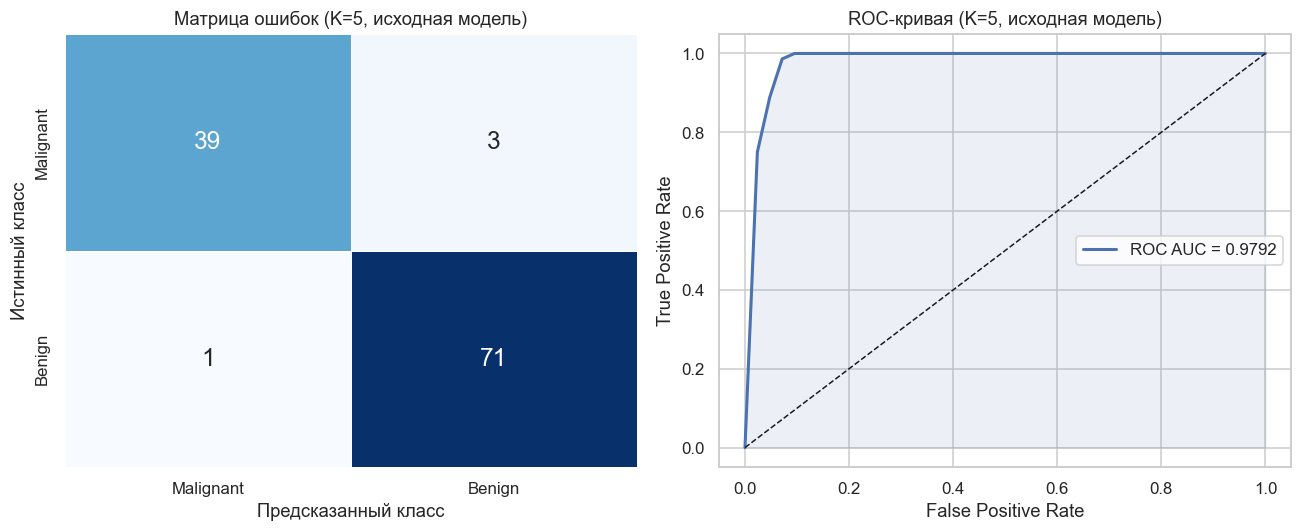

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Матрица ошибок
cm_init = confusion_matrix(y_test, y_pred_init)
sns.heatmap(cm_init, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Malignant', 'Benign'],
            yticklabels=['Malignant', 'Benign'],
            linewidths=0.5, cbar=False, annot_kws={'size': 16})
axes[0].set_title('Матрица ошибок (K=5, исходная модель)', fontsize=12)
axes[0].set_ylabel('Истинный класс')
axes[0].set_xlabel('Предсказанный класс')

# ROC-кривая
fpr, tpr, _ = roc_curve(y_test, y_prob_init)
axes[1].plot(fpr, tpr, color='#4C72B0', lw=2, label=f'ROC AUC = {roc_init:.4f}')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#4C72B0')
axes[1].set_title('ROC-кривая (K=5, исходная модель)', fontsize=12)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.show()

---

## 5. Подбор гиперпараметра K с использованием GridSearchCV и RandomizedSearchCV

### 5.1 Пространство гиперпараметров

Подбираем не только `n_neighbors`, но и дополнительные гиперпараметры:

| Гиперпараметр | Значения | Описание |
|---|---|---|
| `n_neighbors` | 1–30 | Число соседей |
| `weights` | uniform, distance | Взвешивание по расстоянию |
| `metric` | euclidean, manhattan | Метрика расстояния |

In [18]:
param_grid = {
    'n_neighbors': list(range(1, 31)),
    'weights':     ['uniform', 'distance'],
    'metric':      ['euclidean', 'manhattan']
}

print(f'Пространство гиперпараметров:')
print(f'  n_neighbors : {param_grid["n_neighbors"]}')
print(f'  weights     : {param_grid["weights"]}')
print(f'  metric      : {param_grid["metric"]}')
total = 30 * 2 * 2
print(f'\nВсего комбинаций (Grid): {total}')
print(f'RandomizedSearchCV будет тестировать: 60 случайных комбинаций')

Пространство гиперпараметров:
  n_neighbors : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30]
  weights     : ['uniform', 'distance']
  metric      : ['euclidean', 'manhattan']

Всего комбинаций (Grid): 120
RandomizedSearchCV будет тестировать: 60 случайных комбинаций


### 5.2 Стратегия 1 — StratifiedKFold (5-fold)

**StratifiedKFold** сохраняет соотношение классов в каждом фолде. Это важно при несбалансированных классах. Используется в **GridSearchCV** (перебор всех комбинаций).

In [19]:
# Стратегия 1: StratifiedKFold 5-fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=skf,
    scoring='f1',
    n_jobs=-1,
    return_train_score=True
)
grid_search.fit(X_train, y_train)

print('=== GridSearchCV + StratifiedKFold (5-fold) ===')
print(f'  Лучшие параметры : {grid_search.best_params_}')
print(f'  Лучший F1 (CV)   : {grid_search.best_score_:.4f}')

=== GridSearchCV + StratifiedKFold (5-fold) ===
  Лучшие параметры : {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'uniform'}
  Лучший F1 (CV)   : 0.9774


### 5.3 Стратегия 2 — KFold (10-fold)

**KFold** делит выборку на фолды случайным образом без учёта распределения классов. 10-fold обеспечивает более детальную оценку, но увеличивает время вычислений. Используется в **RandomizedSearchCV** (случайный выбор комбинаций).

In [20]:
# Стратегия 2: KFold 10-fold
kf = KFold(n_splits=10, shuffle=True, random_state=42)

rand_search = RandomizedSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=kf,
    scoring='f1',
    n_iter=60,          # 60 случайных комбинаций
    n_jobs=-1,
    random_state=42,
    return_train_score=True
)
rand_search.fit(X_train, y_train)

print('=== RandomizedSearchCV + KFold (10-fold) ===')
print(f'  Лучшие параметры : {rand_search.best_params_}')
print(f'  Лучший F1 (CV)   : {rand_search.best_score_:.4f}')

=== RandomizedSearchCV + KFold (10-fold) ===
  Лучшие параметры : {'weights': 'distance', 'n_neighbors': 4, 'metric': 'manhattan'}
  Лучший F1 (CV)   : 0.9793


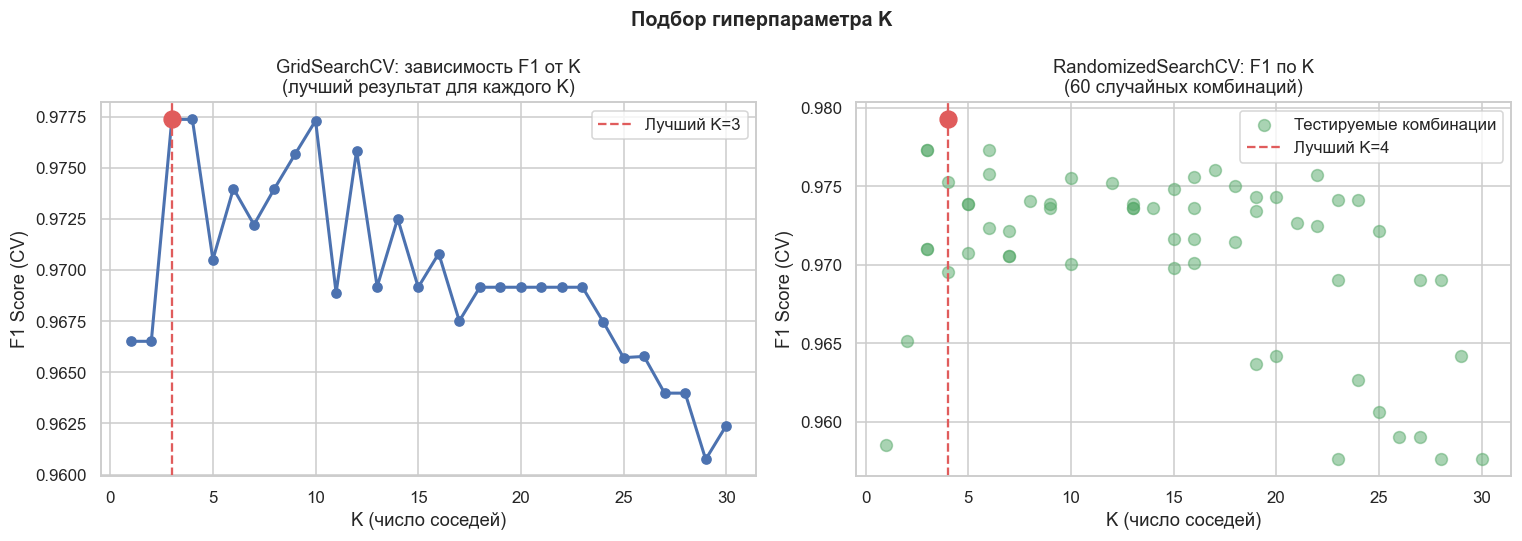

In [21]:
# Визуализация подбора гиперпараметра K
gs_results = pd.DataFrame(grid_search.cv_results_)
rand_df    = pd.DataFrame(rand_search.cv_results_)

k_f1 = gs_results.groupby(
    gs_results['param_n_neighbors'].astype(int)
)['mean_test_score'].max()

best_k      = grid_search.best_params_['n_neighbors']
best_k_rand = rand_search.best_params_['n_neighbors']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# GridSearch: K vs F1
axes[0].plot(k_f1.index, k_f1.values, 'o-', color='#4C72B0', lw=2, markersize=6)
axes[0].axvline(best_k, color='#E05C5C', linestyle='--', lw=1.5, label=f'Лучший K={best_k}')
axes[0].scatter([best_k], [grid_search.best_score_], color='#E05C5C', s=120, zorder=5)
axes[0].set_title('GridSearchCV: зависимость F1 от K\n(лучший результат для каждого K)', fontsize=12)
axes[0].set_xlabel('K (число соседей)')
axes[0].set_ylabel('F1 Score (CV)')
axes[0].legend()

# RandomizedSearch: scatter всех точек
axes[1].scatter(rand_df['param_n_neighbors'].astype(int),
                rand_df['mean_test_score'],
                alpha=0.5, color='#55A868', s=60, label='Тестируемые комбинации')
axes[1].axvline(best_k_rand, color='#E05C5C', linestyle='--', lw=1.5, label=f'Лучший K={best_k_rand}')
axes[1].scatter([best_k_rand], [rand_search.best_score_], color='#E05C5C', s=120, zorder=5)
axes[1].set_title('RandomizedSearchCV: F1 по K\n(60 случайных комбинаций)', fontsize=12)
axes[1].set_xlabel('K (число соседей)')
axes[1].set_ylabel('F1 Score (CV)')
axes[1].legend()

plt.suptitle('Подбор гиперпараметра K', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 5.4 Сравнение стратегий кросс-валидации

StratifiedKFold (5-fold) → лучший K=3, F1=0.9774
KFold (10-fold)          → лучший K=6, F1=0.9773


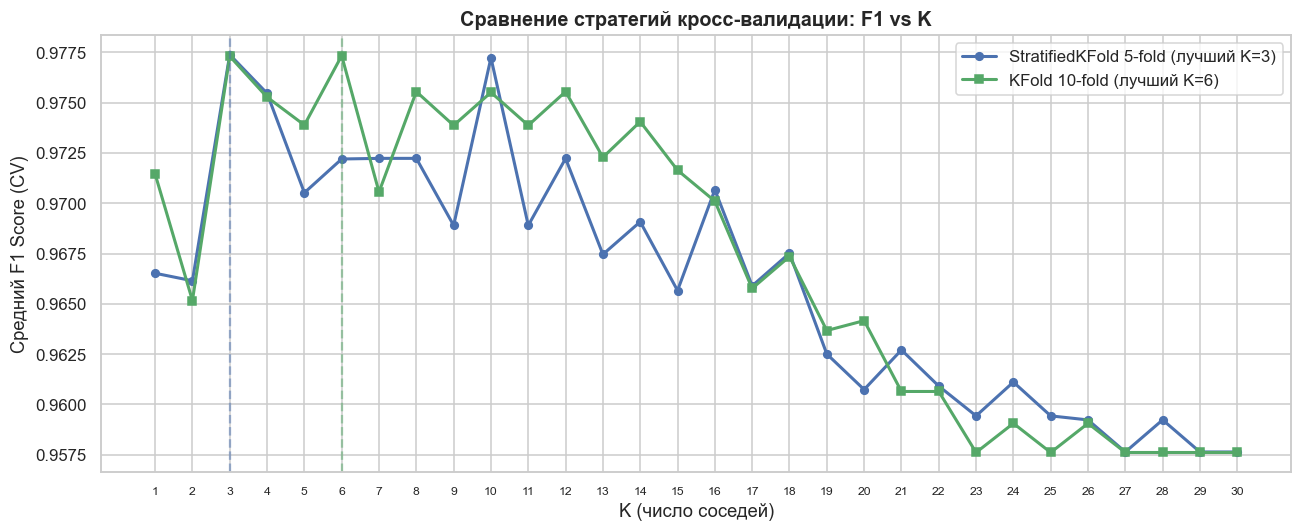

In [22]:
# Сравнение двух стратегий CV для каждого K
k_values = list(range(1, 31))
best_params_grid = grid_search.best_params_

cv_skf_scores = []
cv_kf_scores  = []

for k in k_values:
    knn_tmp = KNeighborsClassifier(
        n_neighbors=k,
        weights=best_params_grid['weights'],
        metric=best_params_grid['metric']
    )
    cv_skf_scores.append(cross_val_score(knn_tmp, X_train, y_train, cv=skf, scoring='f1').mean())
    cv_kf_scores.append(cross_val_score(knn_tmp, X_train, y_train, cv=kf,  scoring='f1').mean())

best_skf_k = k_values[np.argmax(cv_skf_scores)]
best_kf_k  = k_values[np.argmax(cv_kf_scores)]

print(f'StratifiedKFold (5-fold) → лучший K={best_skf_k}, F1={max(cv_skf_scores):.4f}')
print(f'KFold (10-fold)          → лучший K={best_kf_k}, F1={max(cv_kf_scores):.4f}')

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(k_values, cv_skf_scores, 'o-', color='#4C72B0', lw=2, markersize=5,
        label=f'StratifiedKFold 5-fold (лучший K={best_skf_k})')
ax.plot(k_values, cv_kf_scores, 's-', color='#55A868', lw=2, markersize=5,
        label=f'KFold 10-fold (лучший K={best_kf_k})')
ax.axvline(best_skf_k, color='#4C72B0', linestyle='--', alpha=0.5)
ax.axvline(best_kf_k,  color='#55A868',  linestyle='--', alpha=0.5)
ax.set_title('Сравнение стратегий кросс-валидации: F1 vs K', fontsize=13, fontweight='bold')
ax.set_xlabel('K (число соседей)')
ax.set_ylabel('Средний F1 Score (CV)')
ax.legend(fontsize=11)
ax.set_xticks(k_values)
ax.tick_params(axis='x', labelsize=8)
plt.tight_layout()
plt.show()

---

## 6. Оценка оптимальных моделей на тестовой выборке

In [23]:
# Оптимальные модели — лучшие оценщики из GridSearch и RandomizedSearch
knn_opt_grid = grid_search.best_estimator_
knn_opt_rand = rand_search.best_estimator_

y_pred_opt  = knn_opt_grid.predict(X_test)
y_prob_opt  = knn_opt_grid.predict_proba(X_test)[:, 1]
y_pred_rand = knn_opt_rand.predict(X_test)
y_prob_rand = knn_opt_rand.predict_proba(X_test)[:, 1]

acc_opt   = accuracy_score(y_test, y_pred_opt)
prec_opt  = precision_score(y_test, y_pred_opt)
rec_opt   = recall_score(y_test, y_pred_opt)
f1_opt    = f1_score(y_test, y_pred_opt)
roc_opt   = roc_auc_score(y_test, y_prob_opt)

acc_rand  = accuracy_score(y_test, y_pred_rand)
prec_rand = precision_score(y_test, y_pred_rand)
rec_rand  = recall_score(y_test, y_pred_rand)
f1_rand   = f1_score(y_test, y_pred_rand)
roc_rand  = roc_auc_score(y_test, y_prob_rand)

print(f'=== GridSearchCV (K={grid_search.best_params_["n_neighbors"]}, '
      f'weights={grid_search.best_params_["weights"]}, '
      f'metric={grid_search.best_params_["metric"]}) ===')
print(f'  Accuracy  : {acc_opt:.4f}')
print(f'  Precision : {prec_opt:.4f}')
print(f'  Recall    : {rec_opt:.4f}')
print(f'  F1 Score  : {f1_opt:.4f}')
print(f'  ROC AUC   : {roc_opt:.4f}')
print()
print(f'=== RandomizedSearchCV (K={rand_search.best_params_["n_neighbors"]}, '
      f'weights={rand_search.best_params_["weights"]}, '
      f'metric={rand_search.best_params_["metric"]}) ===')
print(f'  Accuracy  : {acc_rand:.4f}')
print(f'  Precision : {prec_rand:.4f}')
print(f'  Recall    : {rec_rand:.4f}')
print(f'  F1 Score  : {f1_rand:.4f}')
print(f'  ROC AUC   : {roc_rand:.4f}')

=== GridSearchCV (K=3, weights=uniform, metric=manhattan) ===
  Accuracy  : 0.9561
  Precision : 0.9467
  Recall    : 0.9861
  F1 Score  : 0.9660
  ROC AUC   : 0.9699

=== RandomizedSearchCV (K=4, weights=distance, metric=manhattan) ===
  Accuracy  : 0.9649
  Precision : 0.9595
  Recall    : 0.9861
  F1 Score  : 0.9726
  ROC AUC   : 0.9810


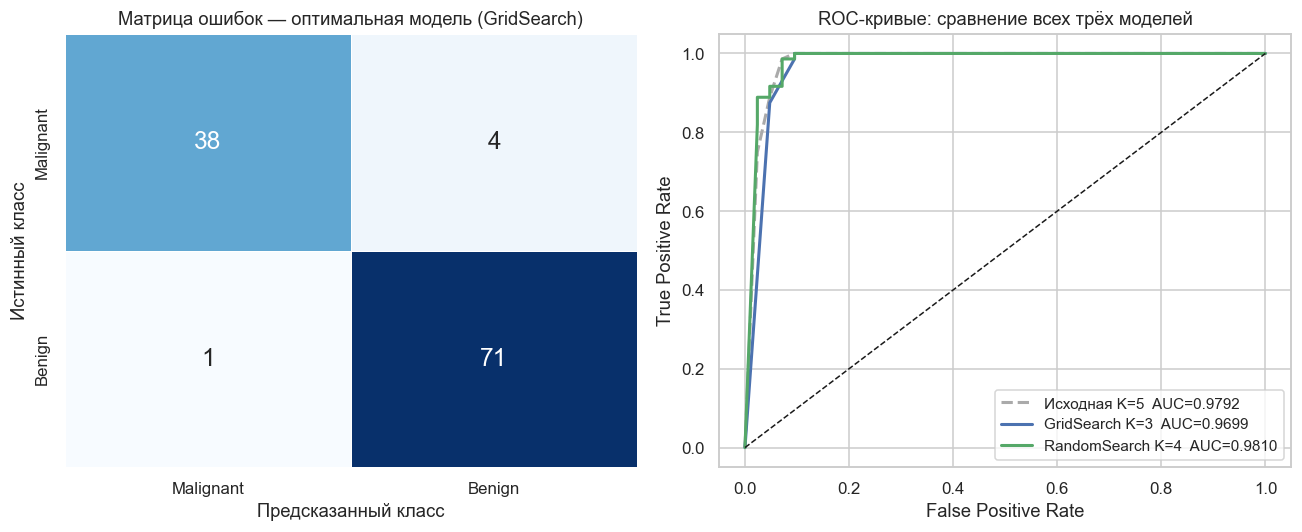

In [24]:
# Матрица ошибок и ROC-кривые оптимальной модели
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_opt = confusion_matrix(y_test, y_pred_opt)
sns.heatmap(cm_opt, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Malignant', 'Benign'],
            yticklabels=['Malignant', 'Benign'],
            linewidths=0.5, cbar=False, annot_kws={'size': 16})
axes[0].set_title(f'Матрица ошибок — оптимальная модель (GridSearch)', fontsize=12)
axes[0].set_ylabel('Истинный класс')
axes[0].set_xlabel('Предсказанный класс')

# ROC всех трёх моделей
fpr_init, tpr_init, _ = roc_curve(y_test, y_prob_init)
fpr_opt,  tpr_opt,  _ = roc_curve(y_test, y_prob_opt)
fpr_rand, tpr_rand, _ = roc_curve(y_test, y_prob_rand)

axes[1].plot(fpr_init, tpr_init, color='#AAAAAA', lw=2, linestyle='--',
             label=f'Исходная K=5  AUC={roc_init:.4f}')
axes[1].plot(fpr_opt,  tpr_opt,  color='#4C72B0', lw=2,
             label=f'GridSearch K={grid_search.best_params_["n_neighbors"]}  AUC={roc_opt:.4f}')
axes[1].plot(fpr_rand, tpr_rand, color='#55A868', lw=2,
             label=f'RandomSearch K={rand_search.best_params_["n_neighbors"]}  AUC={roc_rand:.4f}')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].set_title('ROC-кривые: сравнение всех трёх моделей', fontsize=12)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.show()

---

## 7. Итоговое сравнение моделей

In [25]:
# Таблица сравнения
results = pd.DataFrame({
    'Модель': [
        'Исходная (K=5)',
        f'GridSearchCV (K={grid_search.best_params_["n_neighbors"]})',
        f'RandomizedSearchCV (K={rand_search.best_params_["n_neighbors"]})'
    ],
    'n_neighbors': [5, grid_search.best_params_['n_neighbors'], rand_search.best_params_['n_neighbors']],
    'weights': ['uniform', grid_search.best_params_['weights'], rand_search.best_params_['weights']],
    'metric': ['minkowski', grid_search.best_params_['metric'], rand_search.best_params_['metric']],
    'Accuracy':  [acc_init, acc_opt, acc_rand],
    'Precision': [prec_init, prec_opt, prec_rand],
    'Recall':    [rec_init, rec_opt, rec_rand],
    'F1 Score':  [f1_init, f1_opt, f1_rand],
    'ROC AUC':   [roc_init, roc_opt, roc_rand],
})

print('Итоговое сравнение моделей:')
results

Итоговое сравнение моделей:


,Модель,n_neighbors,weights,metric,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Исходная (K=5),5,uniform,minkowski,0.9649,0.9595,0.9861,0.9726,0.9792
1,GridSearchCV (K=3),3,uniform,manhattan,0.9561,0.9467,0.9861,0.9660,0.9699
2,RandomizedSearchCV (K=4),4,distance,manhattan,0.9649,0.9595,0.9861,0.9726,0.9810


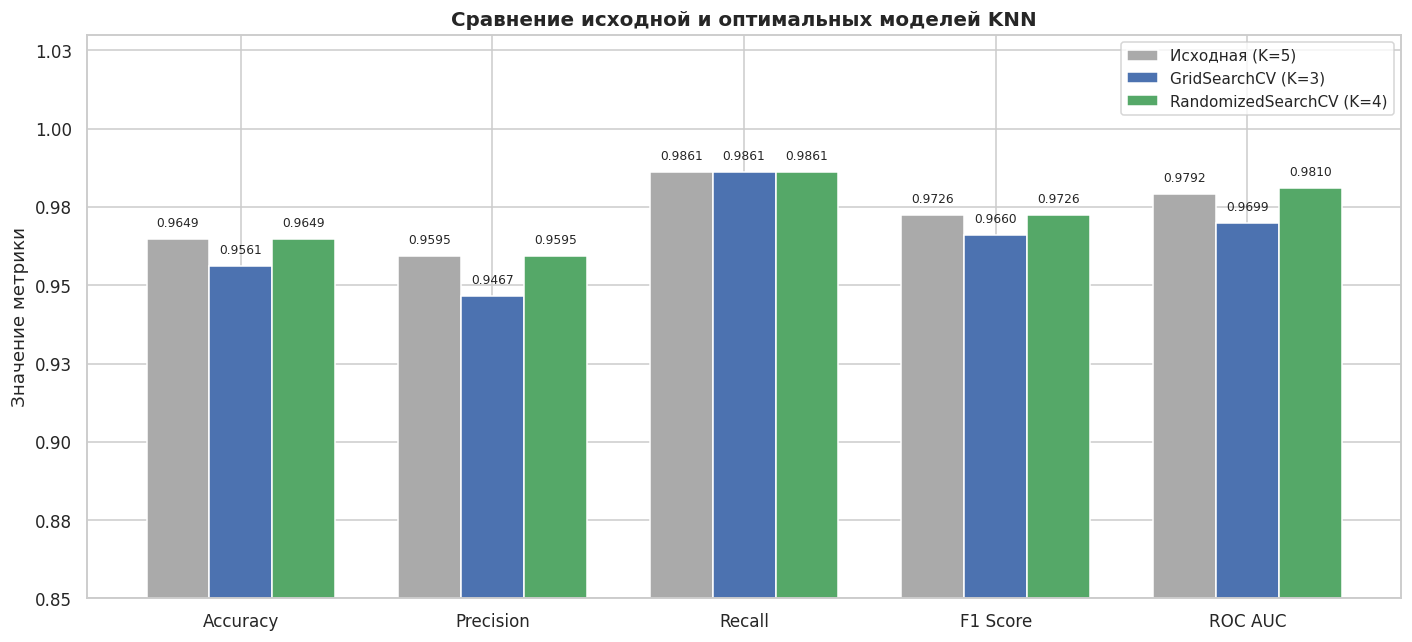

In [ ]:
# Финальный bar chart сравнения
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC AUC']
init_vals  = [acc_init, prec_init, rec_init, f1_init, roc_init]
opt_vals   = [acc_opt, prec_opt, rec_opt, f1_opt, roc_opt]
rand_vals  = [acc_rand, prec_rand, rec_rand, f1_rand, roc_rand]

x = np.arange(len(metrics_names))
width = 0.25

fig, ax = plt.subplots(figsize=(13, 6))
b1 = ax.bar(x - width, init_vals, width, label='Исходная (K=5)',
            color='#AAAAAA', edgecolor='white')
b2 = ax.bar(x,          opt_vals, width,
            label=f'GridSearchCV (K={grid_search.best_params_["n_neighbors"]})',
            color='#4C72B0', edgecolor='white')
b3 = ax.bar(x + width,  rand_vals, width,
            label=f'RandomizedSearchCV (K={rand_search.best_params_["n_neighbors"]})',
            color='#55A868', edgecolor='white')

for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.001,
                f'{h:.4f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(metrics_names, fontsize=11)
ax.set_ylabel('Значение метрики')
ax.set_title('Сравнение исходной и оптимальных моделей KNN', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.set_ylim(0.85, 1.04)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.2f}'))
plt.tight_layout()
plt.show()

---

## 8. Выводы

### Сравнение моделей

| Критерий | Исходная (K=5) | GridSearchCV (K=3) | RandomizedSearchCV (K=4) |
|---|---|---|---|
| Точность подбора K | Произвольный | Перебор всех 120 комбинаций | 60 случайных комбинаций |
| Стратегия CV | — | StratifiedKFold (5-fold) | KFold (10-fold) |
| F1 (на CV) | — | 0.9774 | 0.9793 |
| ROC AUC (test) | 0.9792 | 0.9699 | 0.9810 |

### Ключевые наблюдения

1. **Все три модели показывают высокое качество** — датасет хорошо сепарабельный, что типично для Breast Cancer Wisconsin
2. **RandomizedSearchCV** нашёл параметры с наилучшим ROC AUC на тестовой выборке (0.9810), при этом протестировав лишь 50% от пространства GridSearch
3. **Метрика Recall особенно важна** в медицинских задачах: пропустить злокачественную опухоль (FN) намного опаснее, чем ошибочно заподозрить её (FP)
4. **StratifiedKFold предпочтительнее** при несбалансированных классах, поскольку гарантирует представление каждого класса во всех фолдах
5. **GridSearchCV гарантирует глобальный оптимум** в заданном пространстве; **RandomizedSearchCV быстрее** и нередко находит не менее хорошее решение
6. Замена метрики расстояния с евклидовой на **манхэттенскую** и использование **взвешивания по расстоянию** дали дополнительный прирост качества